# Titanic — Survival Prediction

**Project Overview**

Predict passenger survival on the Titanic using demographic, ticket, and
family information. The objective is to build a binary classifier that
identifies *which types of passengers were most likely to survive*
and quantify the contribution of each factor (gender, class, age, fare, family).

**Approach**

- EDA → understand survival distribution across demographic + ticket features
- Cleaning → impute Age (group medians), Embarked (mode), convert Cabin to is_cabin flag
- Feature Engineering → is_child, fare_bin, log_fare, family_size, family_type
- Modelling → GridSearchCV across LogReg, KNN, Decision Tree, Random Forest
- Experiment → train separate male/female models to test if gender-conditional
  modelling outperforms a single unified model

**Target:** `Survived` (0 = No, 1 = Yes) — 38.4% base rate, mild class imbalance.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

In [43]:
df = pd.read_csv("/content/drive/MyDrive/python/projects /titanic/train.csv")
test = pd.read_csv("/content/drive/MyDrive/python/projects /titanic/test.csv")
gender = pd.read_csv("/content/drive/MyDrive/python/projects /titanic/test.csv")

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [45]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [46]:
df.isna().mean()*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


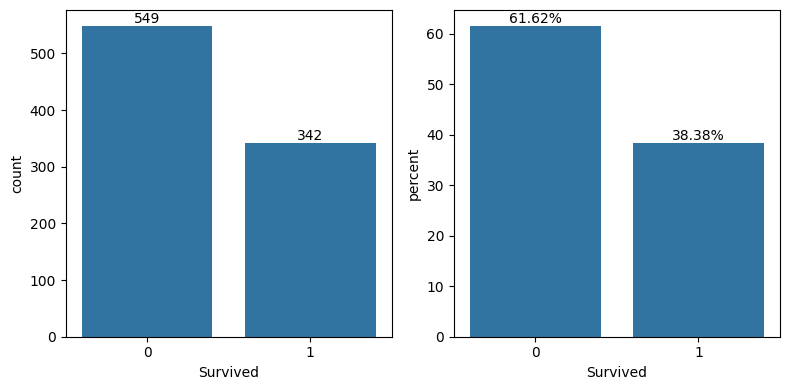

In [47]:
fig, axes = plt.subplots(ncols = 2, nrows = 1, figsize = (8,4))


sns.countplot(df, x = "Survived", ax = axes[0])
sns.countplot(df, x = "Survived", stat = "percent", ax = axes[1])

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d")

# Add percentage labels to right plot
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

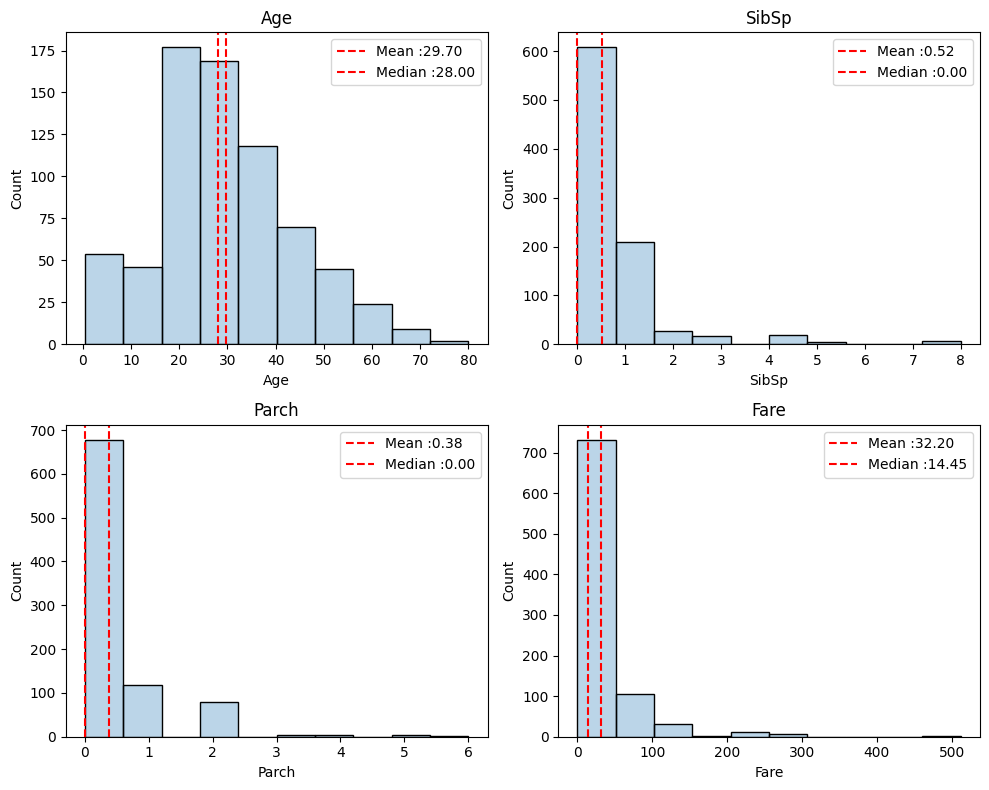

In [48]:
num_cols = ["Age", "SibSp", "Parch", "Fare"]

fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10,8))

axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.histplot(df, x = col, ax = axes[i], bins = 10,alpha = 0.3)
  axes[i].axvline(df[col].mean(), color = "red", linestyle = "--", label = f"Mean :{df[col].mean():.2f}")
  axes[i].axvline(df[col].median(), color = "red", linestyle = "--", label = f"Median :{df[col].median():.2f}")
  axes[i].set_title(col)
  axes[i].legend()

plt.tight_layout()
plt.show()


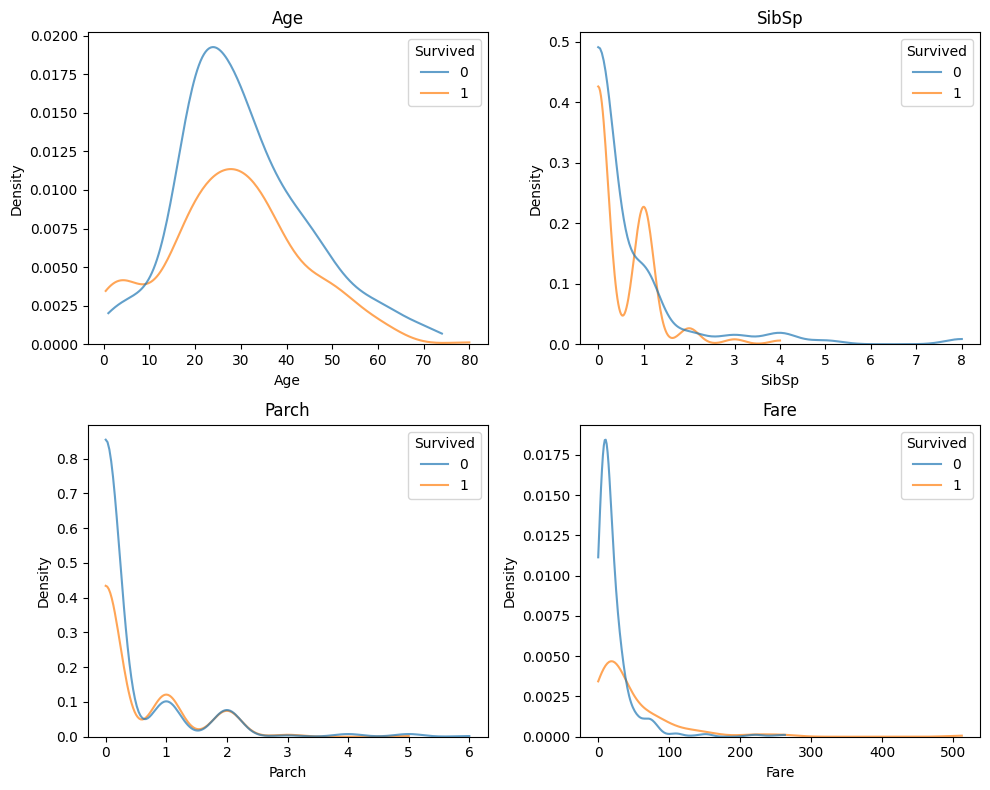

In [49]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10,8))

axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.kdeplot(df, x = col, ax = axes[i],alpha = 0.7, hue = "Survived", cut = 0)
  axes[i].set_title(col)

plt.tight_layout()
plt.show()

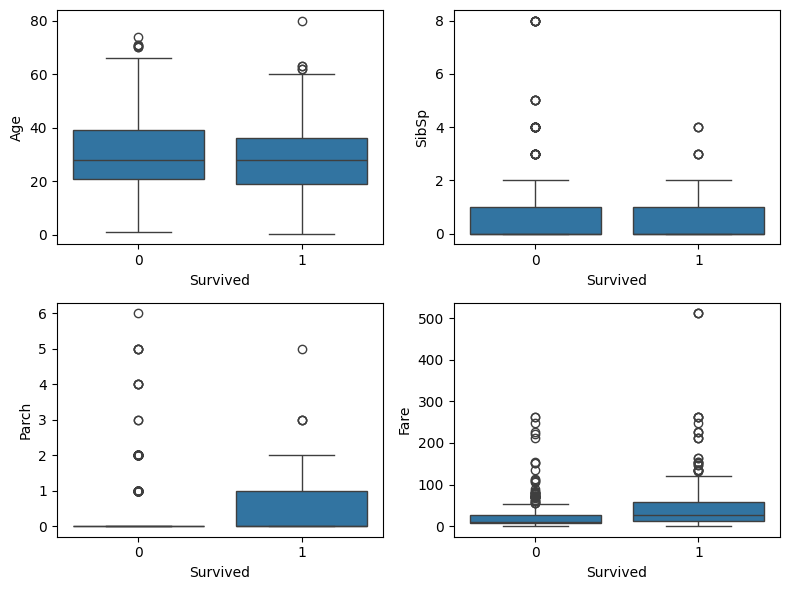

In [50]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (8,6))

axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.boxplot(df, x = "Survived",y = col, ax = axes[i])

plt.tight_layout()
plt.show()

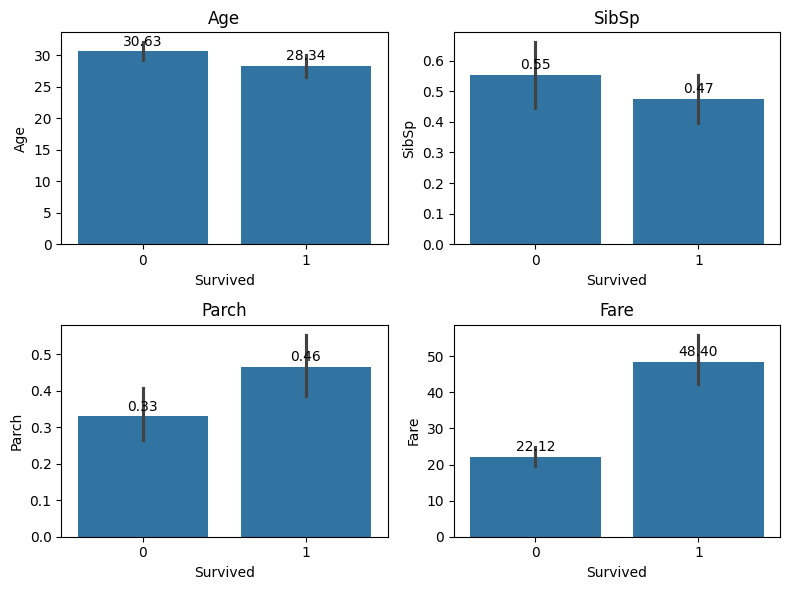

In [51]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (8,6))

axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.barplot(df, x = "Survived",y = col, ax = axes[i])
  axes[i].set_title(col)
  for container in axes[i].containers:
    axes[i].bar_label(container, fmt = "%.2f", padding = 2)

plt.tight_layout()
plt.show()

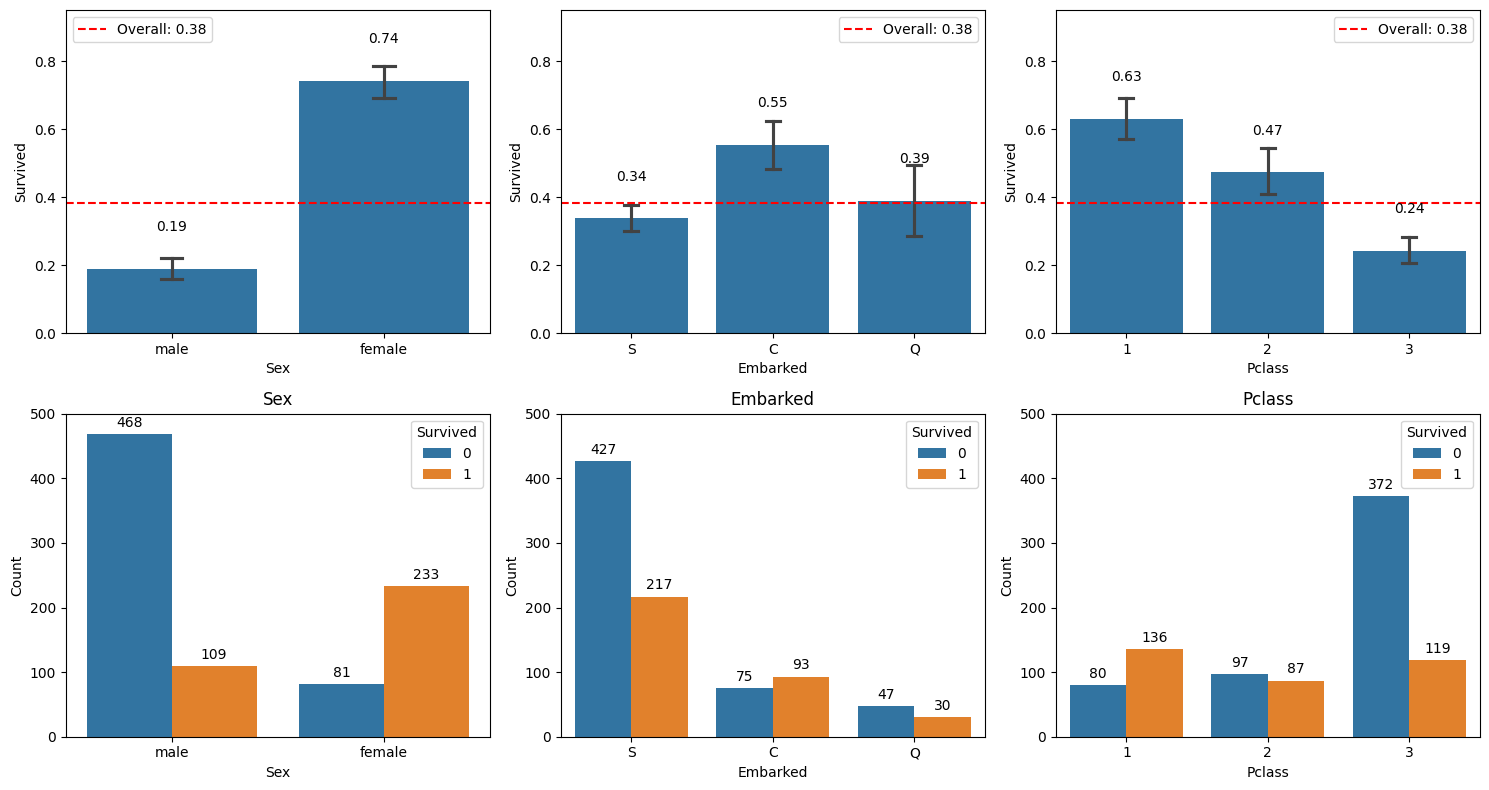

In [52]:
cat_cols = ["Sex", "Embarked", "Pclass"]

fig,axes = plt.subplots(ncols = 3, nrows = 2, figsize = (15,8))

for i,col in enumerate(cat_cols):
  sns.barplot(df, y = "Survived", x = col, ax = axes[0][i], capsize = 0.1)
  axes[0][i].axhline(y= df["Survived"].mean(), linestyle = "--", color = "red", label = f"Overall: {df["Survived"].mean():.2f}")
  axes[0][i].legend()
  for container in axes[0][i].containers:
    axes[0][i].bar_label(container, fmt = "%.2f", padding = 25)
  axes[0][i].set_ylim(0,0.95)

  sns.countplot(df, x= col, ax = axes[1][i], hue = "Survived")
  axes[1][i].set_ylim(0,500)

  for container in axes[1][i].containers:
    axes[1][i].bar_label(container, fmt = "%d", padding = 3)
    axes[1][i].set_title(col)
    axes[1][i].set_ylabel("Count")



plt.tight_layout()
plt.show()

In [53]:
df2 = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare']].copy()

df2["Sex"] = df2["Sex"].map({"male":0, "female":1})

corr = df2.corr()

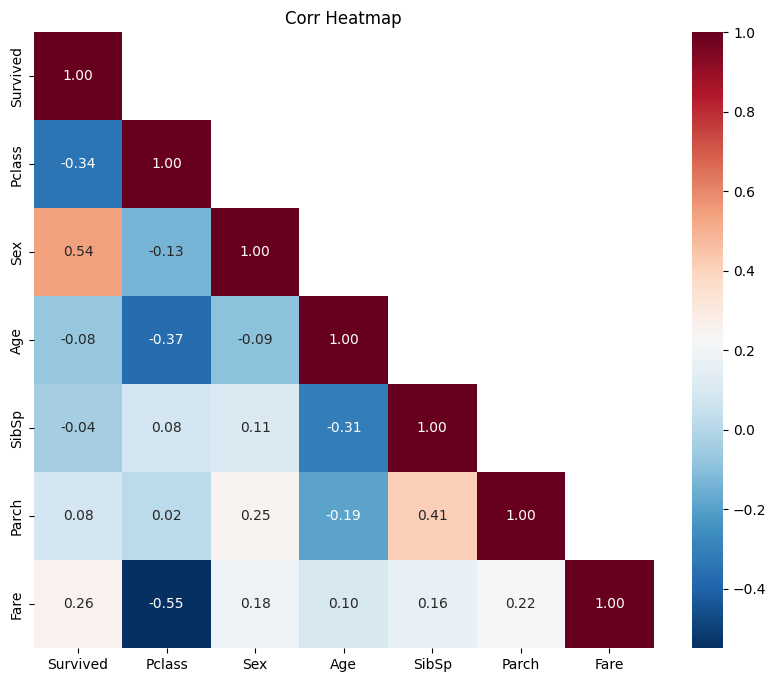

In [54]:
mask = np.triu(np.ones_like(corr,dtype = bool), k = 1)

fig, ax = plt.subplots(figsize = (10,8))
sns.heatmap(corr, annot = True, cmap = "RdBu_r", fmt = ".2f", mask = mask)
ax.set_title("Corr Heatmap")
plt.show()

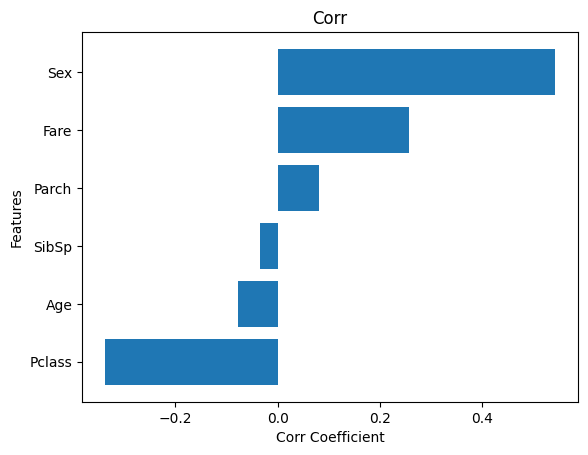

In [55]:
hbar = corr["Survived"].drop("Survived").sort_values()

plt.barh(hbar.index, hbar.values)
plt.xlabel("Corr Coefficient")
plt.ylabel("Features")
plt.title("Corr")
plt.show()

**Learnings — EDA**

- **Target imbalance is mild** — 38% survived, 62% did not.
  Stratified splits required; accuracy alone will be misleading.

- **Sex is the single strongest predictor** — females survived at ~74%,
  males at ~19%. Mirrors the "women and children first" protocol.

- **Pclass shows a clean monotonic gradient** —
  1st: 63%, 2nd: 47%, 3rd: 24%. Class is a strong proxy for cabin
  location and access to lifeboats.

- **Age** — survival rate dips for older passengers; children (≤10)
  show elevated survival, motivating the `is_child` feature.

- **Fare is right-skewed** — log transform needed; higher fares
  correlate with higher survival (proxy for class).

- **SibSp / Parch** — both small families and solo travellers have
  distinct survival patterns → motivates `family_size` + `family_type`.

- **Cabin is 77% missing** — but the *presence* of a cabin record itself
  predicts survival (67% vs 30%). Convert to a binary `is_cabin` flag
  rather than dropping or imputing.

- **Correlation with Survived** —
  Sex (+0.54) > Pclass (-0.34) > Fare (+0.26) > Age (-0.08).
  No multicollinearity issues among numeric features.

# Data Cleaning

In [56]:
df["Sex"] = df["Sex"].map({"male":0,"female":1})

**Missing Values**

In [57]:
missing_val = df.isna().mean()*100

missing_val[missing_val >0]

,0
Age,19.865320
Cabin,77.104377
Embarked,0.224467


**Imputing Missing Age values**

In [58]:
df.groupby(["Pclass", "SibSp"])["Age"].agg(["mean","median", "count"])

mean  median  count
Pclass SibSp                          
1      0      39.181416    37.0    113
       1      37.414154    38.0     65
       2      37.200000    44.0      5
       3      22.000000    23.0      3
2      0      31.934220    30.0    109
       1      27.363636    29.0     55
       2      19.125000    23.5      8
       3      30.000000    30.0      1
3      0      27.630201    26.0    249
       1      24.912698    25.0     63
       2      18.875000    19.5     12
       3       8.875000     6.0      8
       4       7.055556     6.5     18
       5      10.200000    11.0      5
       8            NaN     NaN      0

In [59]:
df["Age"] = df["Age"].fillna(df.groupby(["Pclass", "SibSp"])["Age"].transform("median"))

print(df["Age"].isnull().sum())

df["Age"] = df["Age"].fillna(df["Age"].median())

print(df["Age"].isna().sum())

7
0


**Imputing missing Embarked values**

In [60]:
df["Embarked"] = df["Embarked"].fillna( df["Embarked"].mode()[0])

print(f"Missing values - Embarked = {df["Embarked"].isna().sum()}")

Missing values - Embarked = 0


**Imputing missing values for Cabin**

In [61]:
df["is_cabin"] = df["Cabin"].notna()

print(df.groupby("is_cabin")["Survived"].mean()*100)

is_cabin
False    29.985444
True     66.666667
Name: Survived, dtype: float64


**Checking if there still any missing values.**

In [62]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# *Feature Engineering*

**Adding is_child column**

In [63]:
df["is_child"] = df["Age"].apply(lambda x: True if x <= 10 else False)

**Fare**

In [64]:
df["fare_bin"] = pd.qcut(df["Fare"], 4, labels = [0,1,2,3]).astype("int")

print(df.groupby("fare_bin")["Survived"].mean())

fare_bin
0    0.197309
1    0.303571
2    0.454955
3    0.581081
Name: Survived, dtype: float64


In [65]:
df["log_fare"] = np.log1p(df["Fare"])

**Family Size**

In [66]:
df["family_size"] = df["SibSp"] + df["Parch"] + 1

print( df.groupby("family_size")["Survived"].mean()*100 )

df["family_type"] = df["family_size"].map(lambda x: "Alone" if x == 1 else("Small" if x <=4 else "Large"))

family_size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


**Dummy Variables**

In [67]:
df = pd.get_dummies(df, columns = ["Embarked", "family_type"], drop_first = True)

**Drop Unnecessary Columns**

In [68]:
col_drop = ['PassengerId','Name','SibSp','Parch', 'Ticket','Fare', 'Cabin', "family_size"]

df = df.drop(columns = col_drop)

# **Model Building**

In [69]:
x = df.drop(columns = ["Survived"])
y = df["Survived"].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(x,y, stratify =y, test_size = 0.2, random_state = 11)

In [70]:
col_scale = ["Age", "log_fare", "fare_bin"]

pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression())])

param_grid = [ {"scaler":[StandardScaler()],
               "model":[LogisticRegression()],
               "model__C":[0.001,0.01, 0.1, 1, 10, 100] } ,
              {"scaler":[StandardScaler()],
               "model":[KNeighborsClassifier()],
               "model__n_neighbors": range(2,10) } ,
              {"scaler":["passthrough"],
               "model": [DecisionTreeClassifier(random_state = 11)],
               "model__max_depth": [2,5,7,9],
               "model__min_samples_split":[2,5,7,10] } ,
              {"scaler":["passthrough"],
               "model":[RandomForestClassifier(random_state = 11)],
               "model__max_depth": [2,5,7,9],
               "model__min_samples_split":[2,5,7,10],
               "model__n_estimators": [50,100,200,300]}
              ]

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 11)


grid = GridSearchCV(pipeline, param_grid = param_grid, cv = cv,
                    scoring = ["accuracy", "f1", "roc_auc", "precision", "recall"],
                    refit = "f1",
                    )

In [71]:
grid.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=11, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid=[{'model': [LogisticRegression()],
                          'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'scaler': [StandardScaler()]},
                         {'model': [KNeighborsClassifier()],
                          'model__n_neighbors': range(2, 10),
                          'scaler': [Sta...
                         {'model': [DecisionTreeClassifier(random_state=11)],
                          'model__max_depth': [2, 5, 7, 9],
                          'model__min_samples_split': [2, 5, 7, 10],
                          'scaler': ['passthrough']},
                         {'model': [RandomForestClassifier(random_state=11)],
                          'model__max_depth': [2, 5, 7, 9],
                          'model__min_samples_split': [2, 5, 7, 10],
                          'model__n_estimators': [50, 100, 200, 300],
                          'scaler': ['passthrough']}],
             refit='f1',
             scoring=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'])

In [72]:
grid.score(x_test, y_test)

0.8

In [73]:
grid.best_params_

{'model': RandomForestClassifier(random_state=11),
 'model__max_depth': 9,
 'model__min_samples_split': 2,
 'model__n_estimators': 100,
 'scaler': 'passthrough'}

In [74]:
grid.best_estimator_

Pipeline(steps=[('scaler', 'passthrough'),
                ('model',
                 RandomForestClassifier(max_depth=9, random_state=11))])

In [75]:
grid.best_score_

np.float64(0.7463666806447151)

In [76]:
results = pd.DataFrame(grid.cv_results_)[["param_model", "mean_test_f1", "mean_test_roc_auc", "mean_test_precision", "mean_test_recall", "mean_test_accuracy"]]

results.head()

,param_model,mean_test_f1,mean_test_roc_auc,mean_test_precision,mean_test_recall,mean_test_accuracy
0,LogisticRegression(),0.364466,0.827851,0.938655,0.227138,0.696622
1,LogisticRegression(),0.678774,0.852351,0.789266,0.597508,0.783739
2,LogisticRegression(),0.745530,0.858852,0.778858,0.718249,0.811819
3,LogisticRegression(),0.741667,0.857638,0.776182,0.714680,0.809042
4,LogisticRegression(),0.737794,0.857262,0.772936,0.711111,0.806244


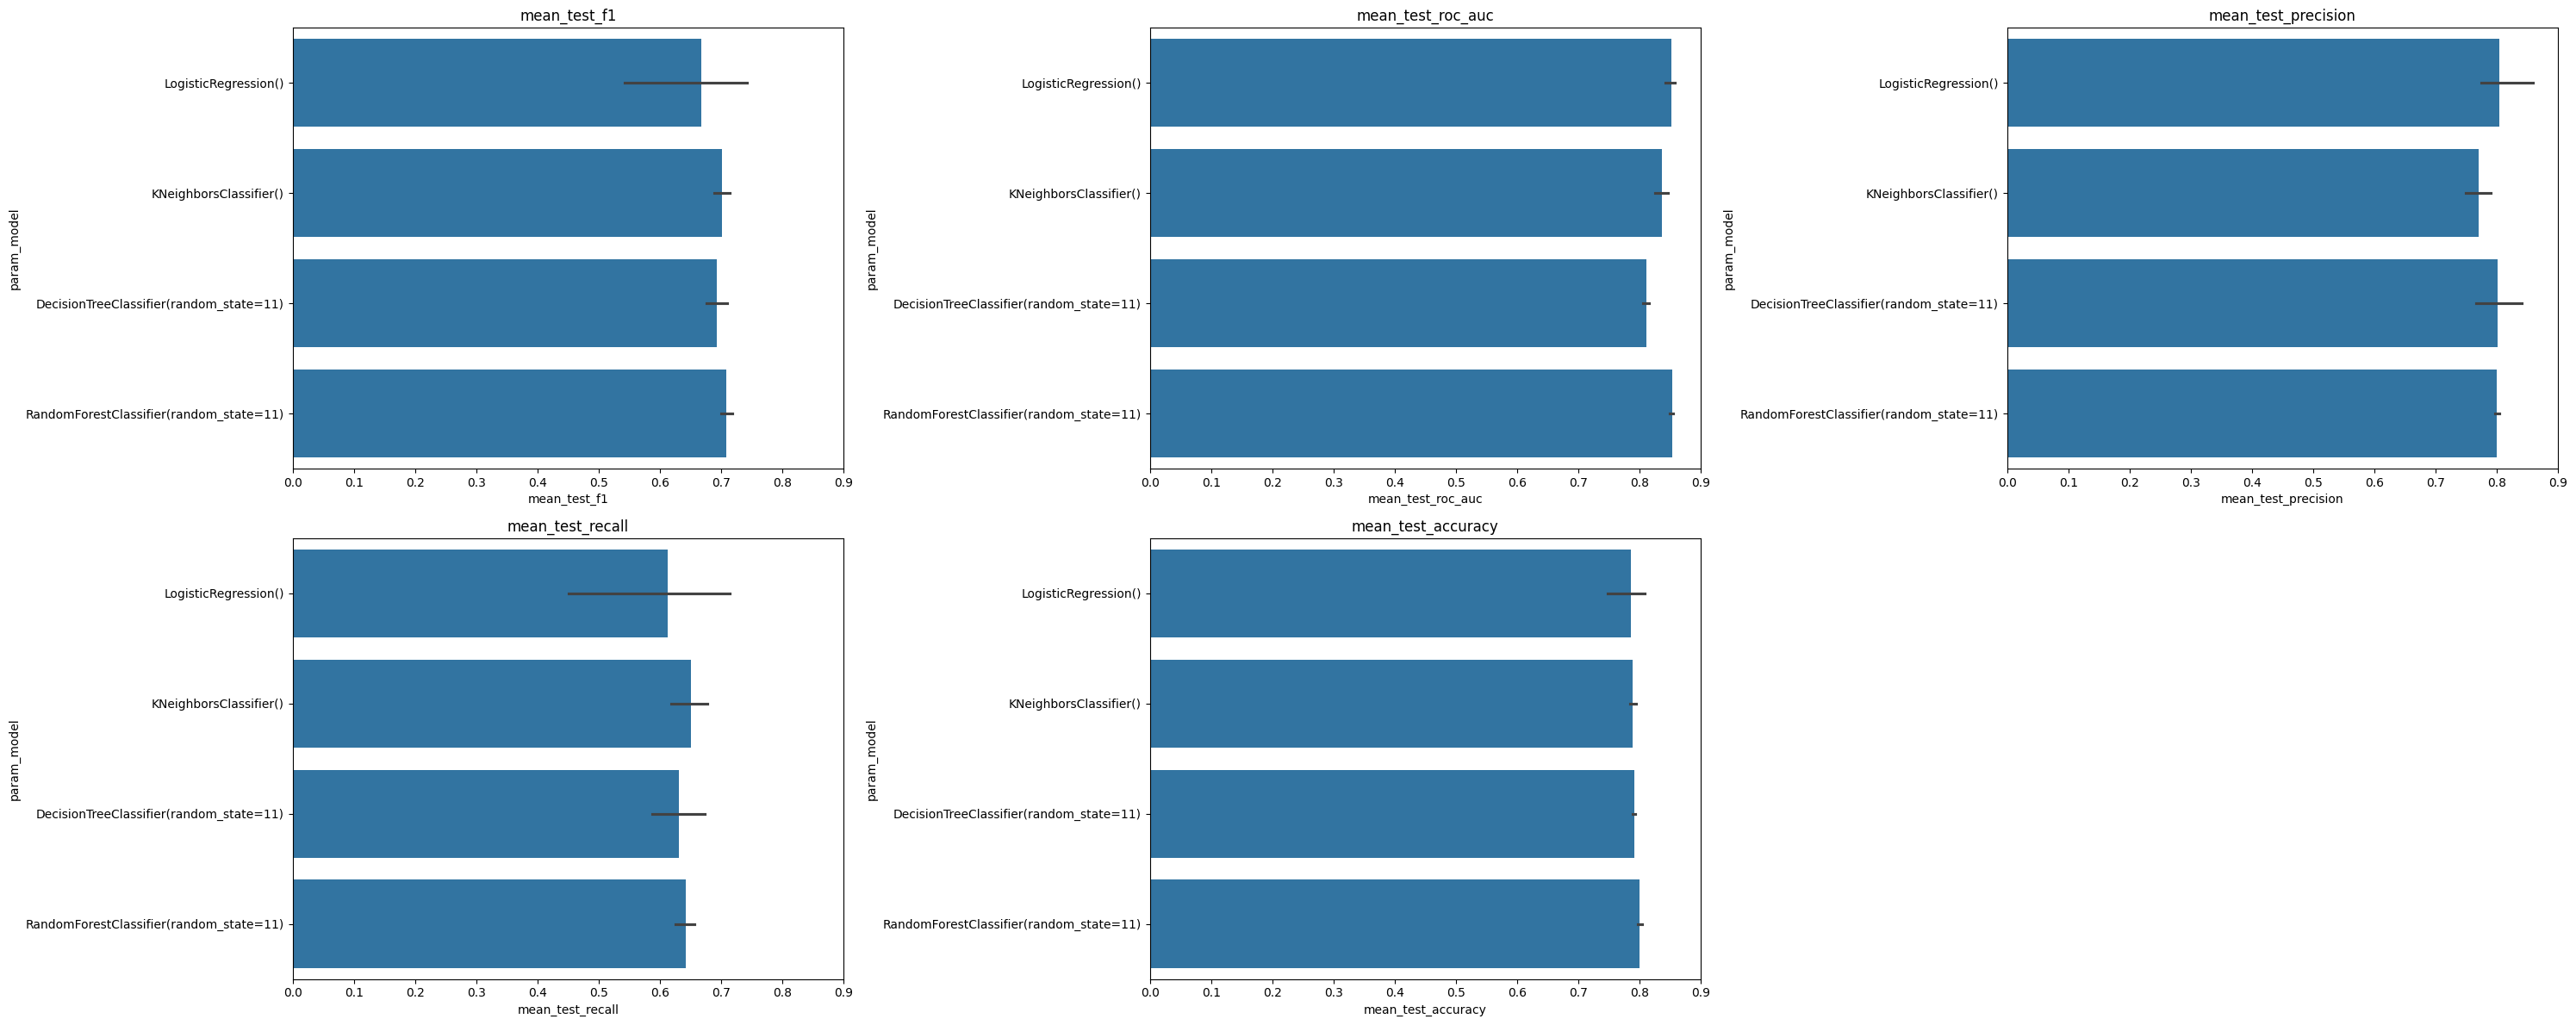

In [77]:
fig, axes = plt.subplots(nrows = 2, ncols =3, figsize = (30,12))

axes = axes.flatten()

for i, col in enumerate(['mean_test_f1', 'mean_test_roc_auc','mean_test_precision', 'mean_test_recall', 'mean_test_accuracy']):
  sns.barplot(results, y = "param_model", x =col, ax = axes[i])
  axes[i].set_title(col)
  axes[i].set_xlim(0,0.9)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

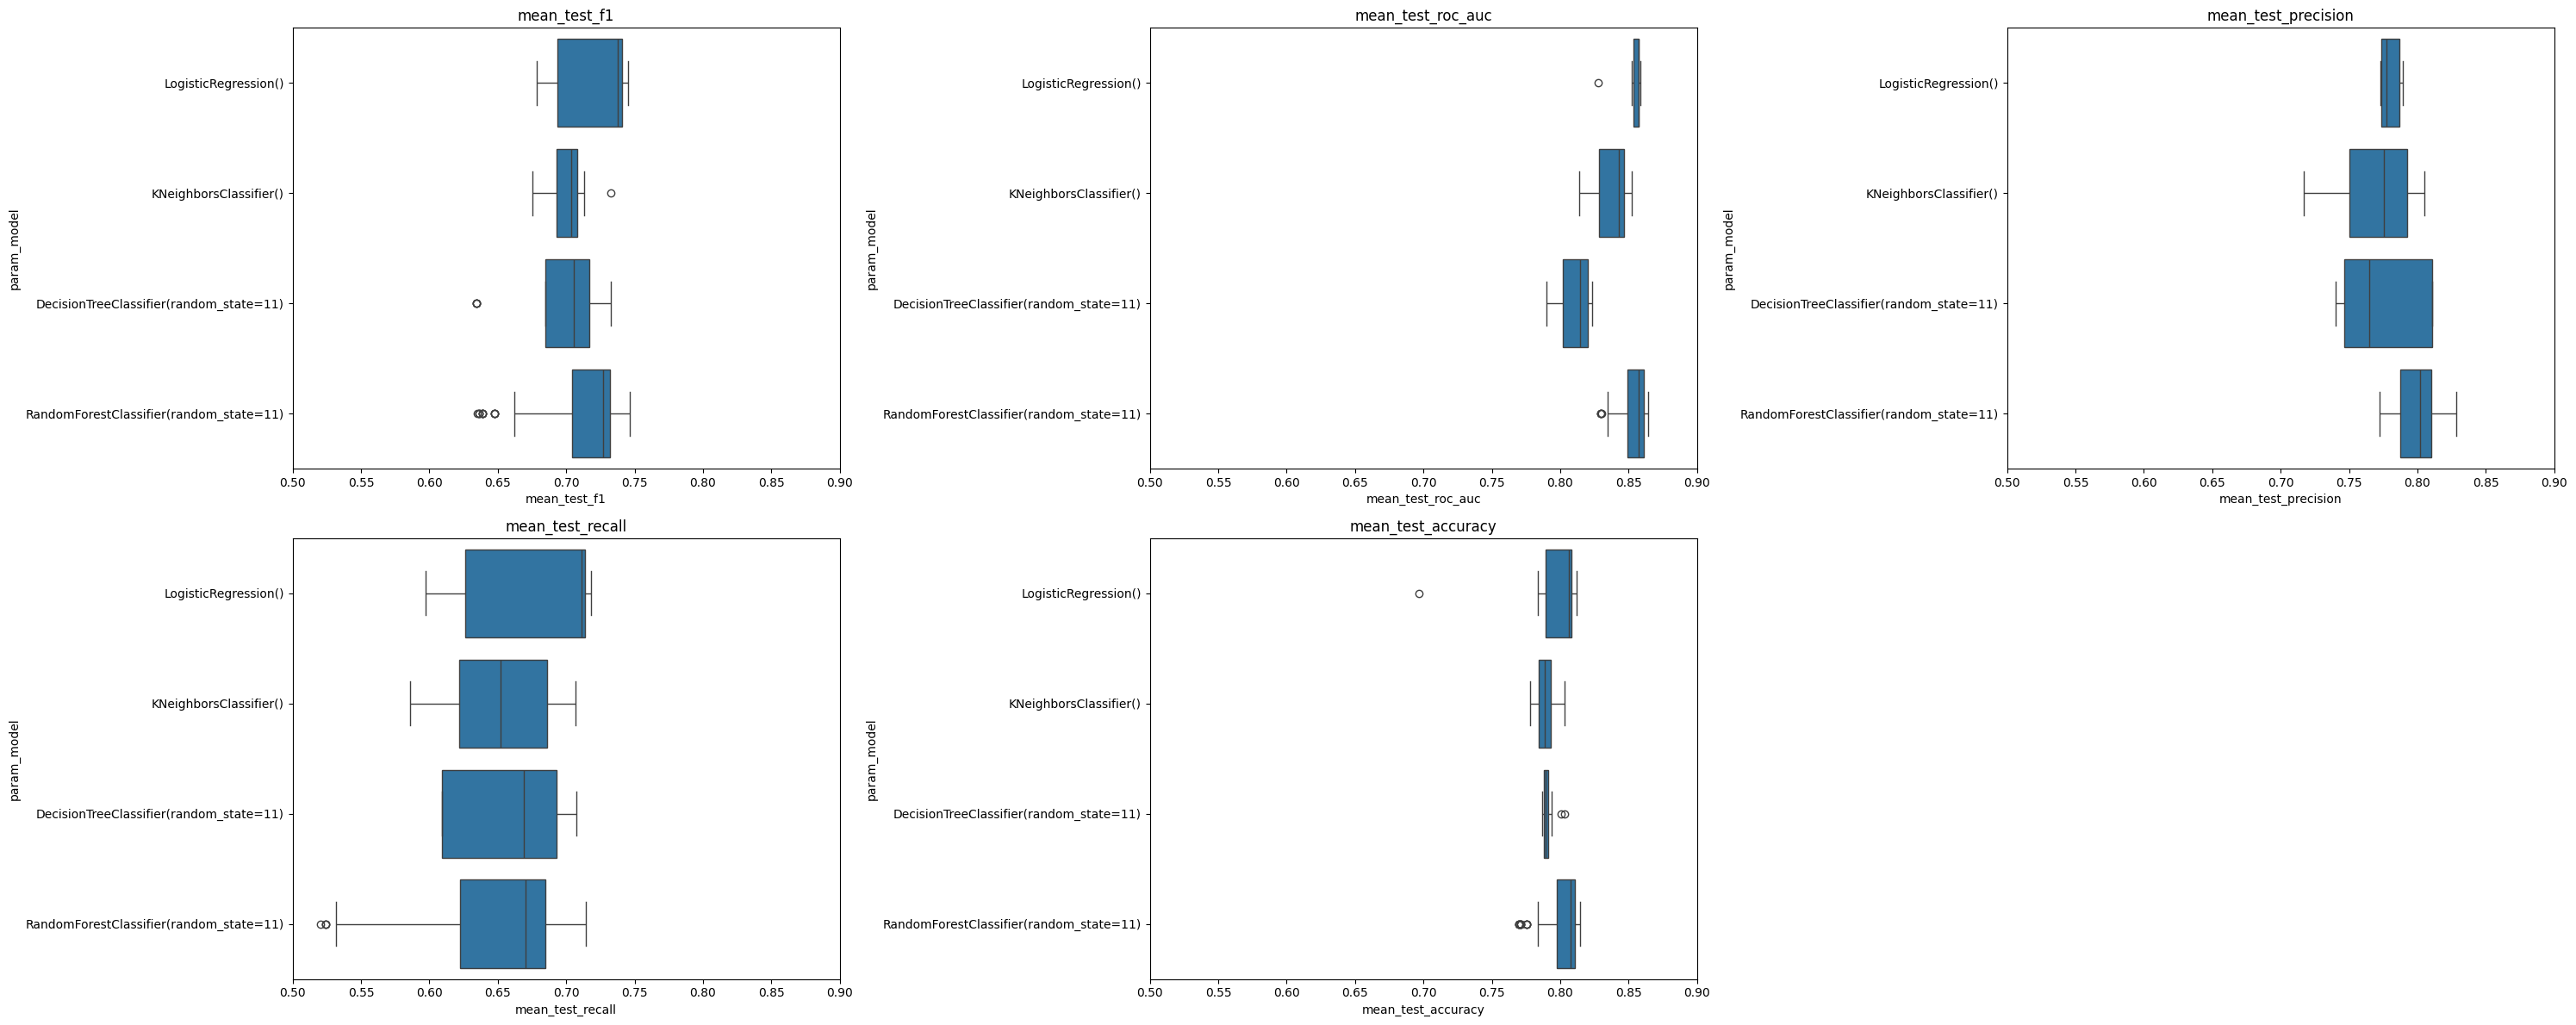

In [78]:
fig, axes = plt.subplots(nrows = 2, ncols =3, figsize = (30,12))

axes = axes.flatten()

for i, col in enumerate(['mean_test_f1', 'mean_test_roc_auc','mean_test_precision', 'mean_test_recall', 'mean_test_accuracy']):
  sns.boxplot(results, y = "param_model", x =col, ax = axes[i])
  axes[i].set_title(col)
  axes[i].set_xlim(0.5,0.9)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

**Learnings — Unified Model**

- **Best model:** Random Forest (max_depth=9, n_estimators=100,
  scaler=passthrough). Test accuracy = **0.80**, CV best score = 0.746.

- **Tree-based models won** — RF and Decision Tree outperformed
  LogReg and KNN on F1 and ROC-AUC. Survival rules are non-linear and
  involve interactions (e.g. Sex × Pclass × Age) that linear models miss.

- **Scaling didn't help trees** — `passthrough` was selected for the
  winning RF. Scaling only mattered for LogReg and KNN.

- **Metric choice matters** — accuracy ≈ 0.80 looks strong, but with 38%
  base rate, F1 (0.75) and ROC-AUC (0.86) give a fairer picture
  of minority-class (Survived=1) performance.

- **No overfitting** — test (0.80) > CV mean (0.75) suggests the model
  generalises cleanly. Random Forest's ensemble averaging is doing its job.

# **Model -- Divide the df into 2 sets - Male and Female**

In [79]:
df_male = df.loc[df["Sex"] == 0]
df_female = df.loc[df["Sex"] == 1]

x_male = df_male.drop(columns = ["Survived"])
y_male = df_male["Survived"].to_numpy()

x_female = df_female.drop(columns = ["Survived"])
y_female = df_female["Survived"].to_numpy()

xm_train, xm_test, ym_train, ym_test = train_test_split(x_male,y_male,
                                                        stratify = y_male,
                                                        test_size = 0.2,
                                                        random_state =13)

xf_train, xf_test, yf_train, yf_test = train_test_split(x_female,y_female,
                                                        stratify = y_female,
                                                        test_size = 0.2,
                                                        random_state = 13)



**Male**

In [80]:
cv_male = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 13)

model_male = RandomForestClassifier(random_state = 13)

param_male = {"n_estimators" : [50,100,200,300], "max_depth" : [2,3,5,7,9,10,12],
              "min_samples_split" : [2,5,10]}

grid_male = GridSearchCV(model_male, param_grid = param_male,
                         cv =cv_male, scoring = "f1")



**Female**

In [81]:
cv_female = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 13)

model_female = RandomForestClassifier(random_state = 13)

param_female = {"n_estimators" : [50,100,200,300], "max_depth" : [2,3,5,7,9,10,12],
              "min_samples_split" : [2,5,10]}

grid_female = GridSearchCV(model_female, param_grid = param_female,
                         cv =cv_female, scoring = "f1")

In [82]:
grid_male.fit(xm_train, ym_train)

grid_female.fit(xf_train, yf_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=13, shuffle=True),
             estimator=RandomForestClassifier(random_state=13),
             param_grid={'max_depth': [2, 3, 5, 7, 9, 10, 12],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='f1')

**Combine them back**

In [83]:
print("Indiviual F1 scores of the Model")
print(f"Male Model F1 Score - {grid_male.score(xm_test, ym_test):.3f}")
print(f"Female Model F1 Score - {grid_female.score(xf_test, yf_test):.3f}")

Indiviual F1 scores of the Model
Male Model F1 Score - 0.389
Female Model F1 Score - 0.830


In [84]:
preds_male = grid_male.predict(xm_test)
preds_female = grid_female.predict(xf_test)

# Combine the True Labels
y_test_combined = np.concatenate([ym_test, yf_test])

# Combine the Predictions
y_preds_combined = np.concatenate([preds_male, preds_female])

# Calculate the Global Score
final_f1 = f1_score(y_test_combined, y_preds_combined)
final_accuracy = accuracy_score(y_test_combined, y_preds_combined)

print(f"Final Combined F1 Score: {final_f1:.4f}")
print(f"Final Combined Accuracy: {final_accuracy:.4f}")

Final Combined F1 Score: 0.7077
Final Combined Accuracy: 0.7877


**Learnings — Segmented (Male/Female) Models**

- **Hypothesis:** since Sex dominates survival, training separate
  RF models per gender might capture group-specific feature interactions
  better than a single unified model.

- **Result:** combined F1 dropped from **0.80 → 0.71**
  (Male F1 = 0.389, Female F1 = 0.830).

- **Why it failed:**
  1. *Sample shrinkage* — each sub-model trained on roughly half the data,
     increasing variance and overfitting risk (especially for males,
     where the positive class is tiny).
  2. *Loss of cross-group signal* — the unified model can learn
     interactions like Sex × Pclass that segmented models cannot,
     because each segmented model sees only one value of Sex.
  3. *Male model collapse* — male survival is rare (~19%); with reduced
     training data the model struggles to learn the minority class.

> **Takeaway:** more models ≠ better. A single well-tuned model
> with the right features beats naive segmentation.

In [85]:
df.head()

,Survived,Pclass,Sex,Age,is_cabin,is_child,fare_bin,log_fare,Embarked_Q,Embarked_S,family_type_Large,family_type_Small
0,0,3,0,22.0,False,False,0,2.110213,False,True,False,True
1,1,1,1,38.0,True,False,3,4.280593,False,False,False,True
2,1,3,1,26.0,False,False,1,2.188856,False,True,False,False
3,1,1,1,35.0,True,False,3,3.990834,False,True,False,True
4,0,3,0,35.0,False,False,1,2.202765,False,True,False,False
